# EDA: Trip Distance & Location Distribution

Performs exploratory data analysis on the merged FHV trip + vehicle emissions dataset to understand:
- Trip distance distributions overall and by vehicle class
- Most common pickup and dropoff zone locations
- CO₂ emissions patterns across vehicle classes
- Share of pooled vs. solo trips

**Data source:** `data/FHVTrip_VehicleEmissions_Merged_2023.csv`  
**Vehicle fleet split:** SUV 52% | Sedans 36% | Minivans 12%

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Data

In [2]:
DATA_PATH = "../data/FHVTrip_VehicleEmissions_Merged_2023.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

# Coerce types
df["trip_miles"] = pd.to_numeric(df["trip_miles"], errors="coerce")
df["trip_time"]  = pd.to_numeric(df["trip_time"],  errors="coerce")
df["co2TailpipeGpm"] = pd.to_numeric(df["co2TailpipeGpm"], errors="coerce")
df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head(3)

/var/folders/bc/bnxc12vn183dxdj_54b36g9r0000gn/T/ipykernel_79923/3341870687.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
/var/folders/bc/bnxc12vn183dxdj_54b36g9r0000gn/T/ipykernel_79923/3341870687.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")


Rows: 2,064,852  |  Columns: 21


,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,...,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,VClass,co2TailpipeGpm,city08,fuelCost08,fuelType
0,12/31/2022 11:57:44 PM,NaN,2023-01-01 00:07:15,2023-01-01 00:44:36,10,62,11.589,NaN,30.79,0.0,...,0.0,0.0,Y,Y,N,SUV,511.290035,16.200270,2587.125506,Regular
1,01/01/2023 12:16:32 AM,NaN,2023-01-01 00:41:26,2023-01-01 01:09:55,210,39,4.699,NaN,14.51,0.0,...,0.0,0.0,Y,Y,N,Minivans,449.477404,17.906183,2164.605544,Regular
2,01/01/2023 12:01:00 AM,NaN,2023-01-01 00:49:39,2023-01-01 01:28:08,155,177,7.008,NaN,16.32,0.0,...,0.0,0.0,Y,Y,N,Sedans,398.427478,22.618561,2199.776051,Premium


In [3]:
df[["trip_miles", "trip_time", "co2TailpipeGpm", "city08", "fuelCost08"]].describe().round(2)

,trip_miles,trip_time,co2TailpipeGpm,city08,fuelCost08
count,2064852.00,418910.00,2064852.00,2064852.00,2064852.00
mean,6.74,729.13,463.27,18.71,2397.10
std,4.51,189.40,52.30,2.98,198.19
min,0.00,0.00,398.43,16.20,2164.61
25%,3.44,601.00,398.43,16.20,2199.78
50%,5.67,760.00,511.29,16.20,2587.13
75%,8.90,886.00,511.29,22.62,2587.13
max,112.81,999.00,511.29,22.62,2587.13


## 2. Trip Distance Distribution

Understanding how far trips typically travel informs which solo rides are feasible pooling candidates.

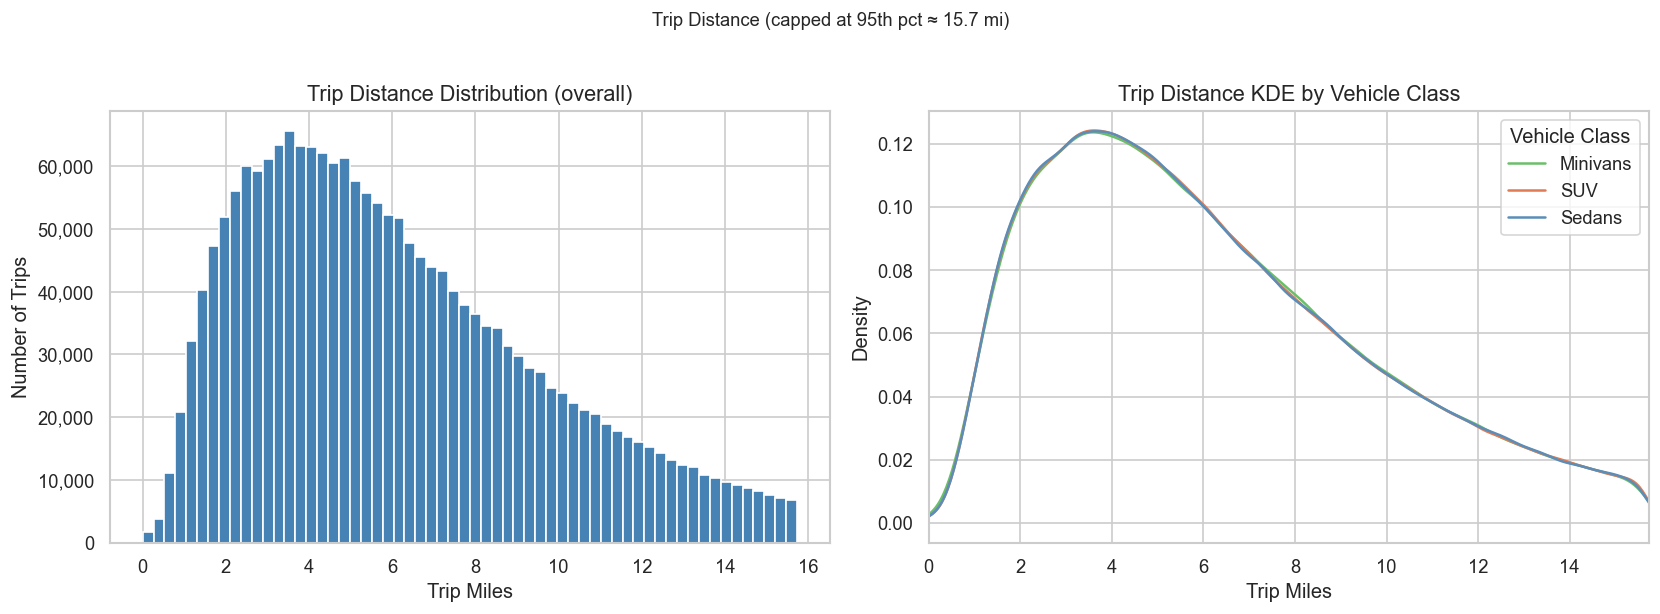

Median: 5.67 mi  |  Mean: 6.74 mi


In [4]:
# Cap at 95th percentile to reduce visual distortion from extreme outliers
dist_cap = df["trip_miles"].quantile(0.95)
df_dist = df[df["trip_miles"] <= dist_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall histogram
axes[0].hist(df_dist["trip_miles"], bins=60, edgecolor="white", color="steelblue")
axes[0].set_title("Trip Distance Distribution (overall)", fontsize=13)
axes[0].set_xlabel("Trip Miles")
axes[0].set_ylabel("Number of Trips")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right: KDE by vehicle class
palette = {"SUV": "#e07b54", "Sedans": "#5b8db8", "Minivans": "#6abf69"}
for vclass, grp in df_dist.groupby("VClass"):
    grp["trip_miles"].plot.kde(ax=axes[1], label=vclass, color=palette.get(vclass))
axes[1].set_title("Trip Distance KDE by Vehicle Class", fontsize=13)
axes[1].set_xlabel("Trip Miles")
axes[1].set_ylabel("Density")
axes[1].legend(title="Vehicle Class")
axes[1].set_xlim(0, dist_cap)

plt.suptitle(f"Trip Distance (capped at 95th pct ≈ {dist_cap:.1f} mi)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
print(f"Median: {df['trip_miles'].median():.2f} mi  |  Mean: {df['trip_miles'].mean():.2f} mi")

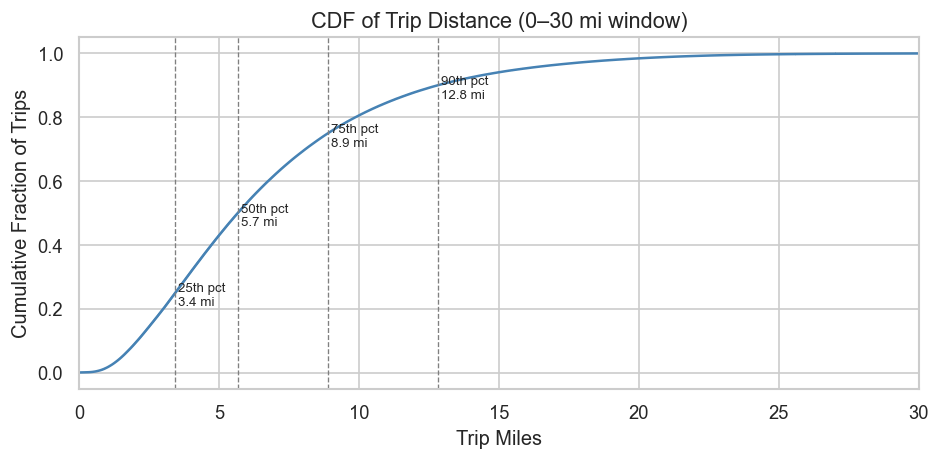

In [5]:
# Cumulative distribution — useful for setting a "pooling window" threshold
fig, ax = plt.subplots(figsize=(8, 4))
sorted_miles = np.sort(df["trip_miles"].dropna())
cdf = np.arange(1, len(sorted_miles) + 1) / len(sorted_miles)

ax.plot(sorted_miles, cdf, color="steelblue", linewidth=1.5)
for pct in [0.25, 0.50, 0.75, 0.90]:
    val = np.quantile(sorted_miles, pct)
    ax.axvline(val, linestyle="--", linewidth=0.8, color="gray")
    ax.text(val + 0.1, pct - 0.04, f"{pct*100:.0f}th pct\n{val:.1f} mi", fontsize=8)

ax.set_xlim(0, 30)
ax.set_title("CDF of Trip Distance (0–30 mi window)", fontsize=13)
ax.set_xlabel("Trip Miles")
ax.set_ylabel("Cumulative Fraction of Trips")
plt.tight_layout()
plt.show()

## 3. Most Common Pickup & Dropoff Locations

NYC TLC zone IDs (`PULocationID` / `DOLocationID`) map to specific taxi zones. High-frequency zones represent the best targets for pooling clusters.

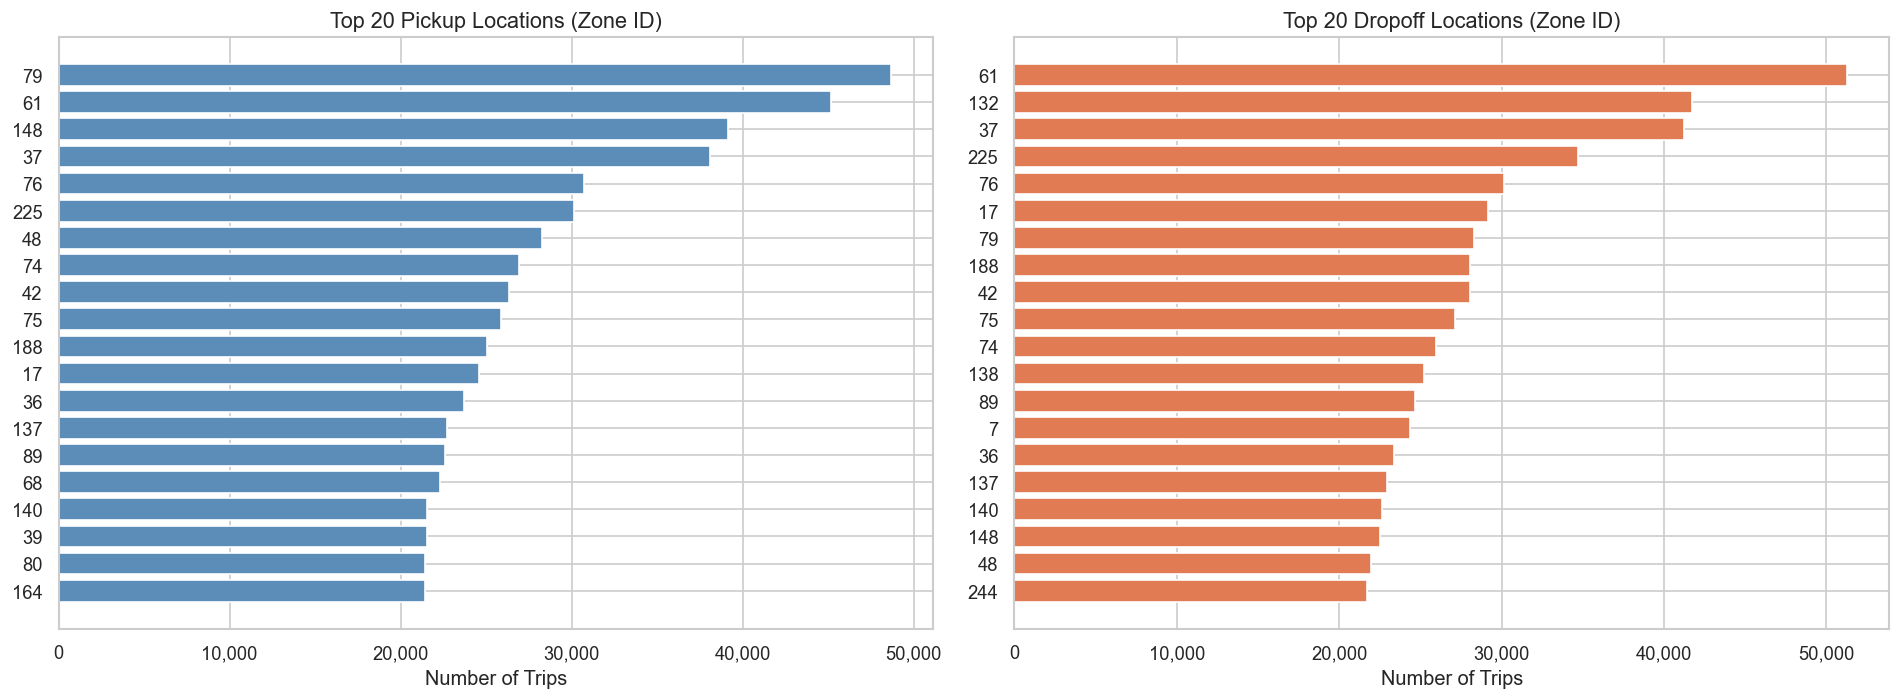

In [6]:
TOP_N = 20

top_pu = df["PULocationID"].value_counts().head(TOP_N).reset_index()
top_pu.columns = ["ZoneID", "count"]

top_do = df["DOLocationID"].value_counts().head(TOP_N).reset_index()
top_do.columns = ["ZoneID", "count"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pickup
axes[0].barh(top_pu["ZoneID"].astype(str)[::-1], top_pu["count"][::-1], color="#5b8db8")
axes[0].set_title(f"Top {TOP_N} Pickup Locations (Zone ID)", fontsize=13)
axes[0].set_xlabel("Number of Trips")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Dropoff
axes[1].barh(top_do["ZoneID"].astype(str)[::-1], top_do["count"][::-1], color="#e07b54")
axes[1].set_title(f"Top {TOP_N} Dropoff Locations (Zone ID)", fontsize=13)
axes[1].set_xlabel("Number of Trips")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

Zones in both top-20 pickup and dropoff: [17, 36, 37, 42, 48, 61, 74, 75, 76, 79, 89, 137, 140, 148, 188, 225]


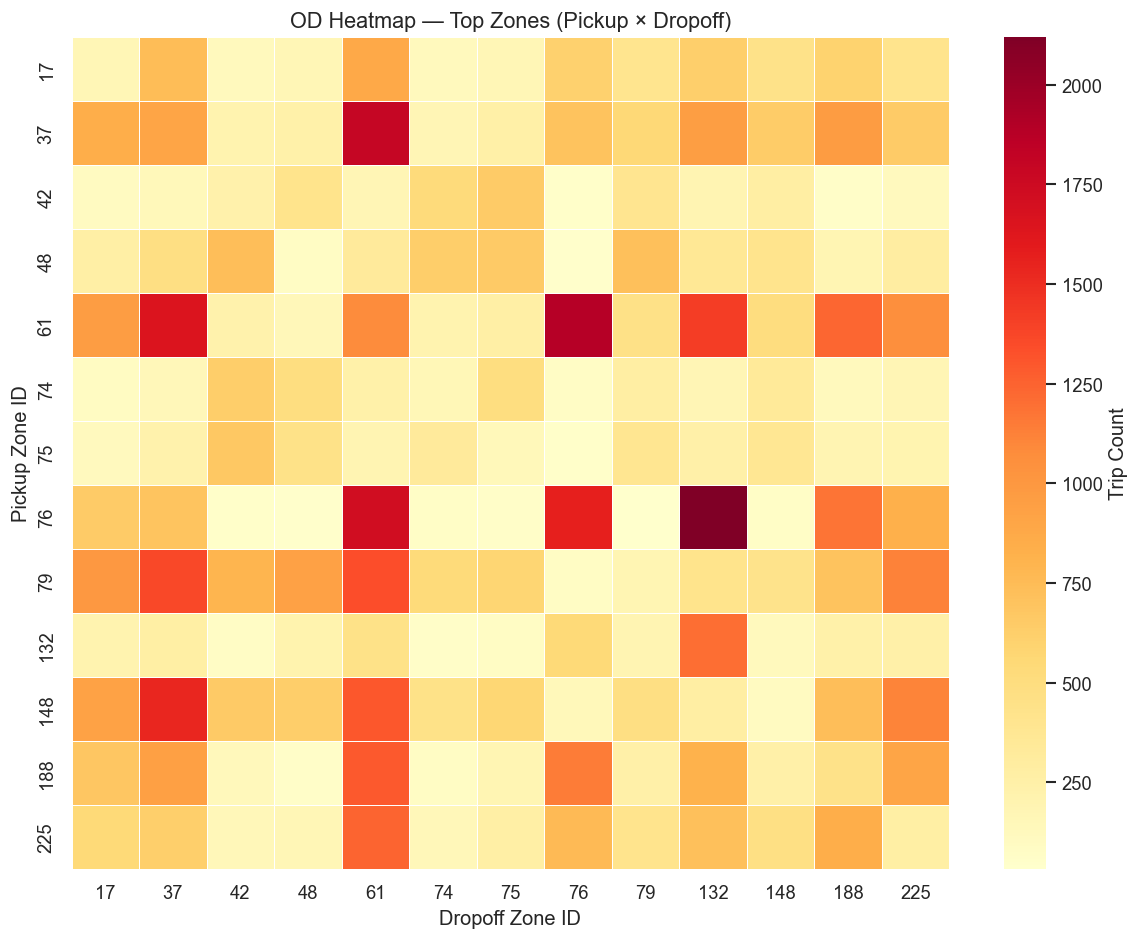

In [7]:
# Which zones appear in BOTH top pickup AND top dropoff lists?
overlap = set(top_pu["ZoneID"]) & set(top_do["ZoneID"])
print(f"Zones in both top-{TOP_N} pickup and dropoff: {sorted(overlap)}")

# Origin-destination heatmap for the top zones (trip volume)
top_zones = sorted(set(top_pu["ZoneID"].tolist()[:10] + top_do["ZoneID"].tolist()[:10]))
od_matrix = (
    df[df["PULocationID"].isin(top_zones) & df["DOLocationID"].isin(top_zones)]
    .groupby(["PULocationID", "DOLocationID"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(od_matrix, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Trip Count"})
ax.set_title("OD Heatmap — Top Zones (Pickup × Dropoff)", fontsize=13)
ax.set_xlabel("Dropoff Zone ID")
ax.set_ylabel("Pickup Zone ID")
plt.tight_layout()
plt.show()

## 4. CO₂ Emissions by Vehicle Class

Each trip's total CO₂ is estimated as `co2TailpipeGpm × trip_miles`. We compare average per-trip emissions across the three fleet categories.

/var/folders/bc/bnxc12vn183dxdj_54b36g9r0000gn/T/ipykernel_79923/886305156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="VClass", y="co2_total_g", order=order,
/var/folders/bc/bnxc12vn183dxdj_54b36g9r0000gn/T/ipykernel_79923/886305156.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


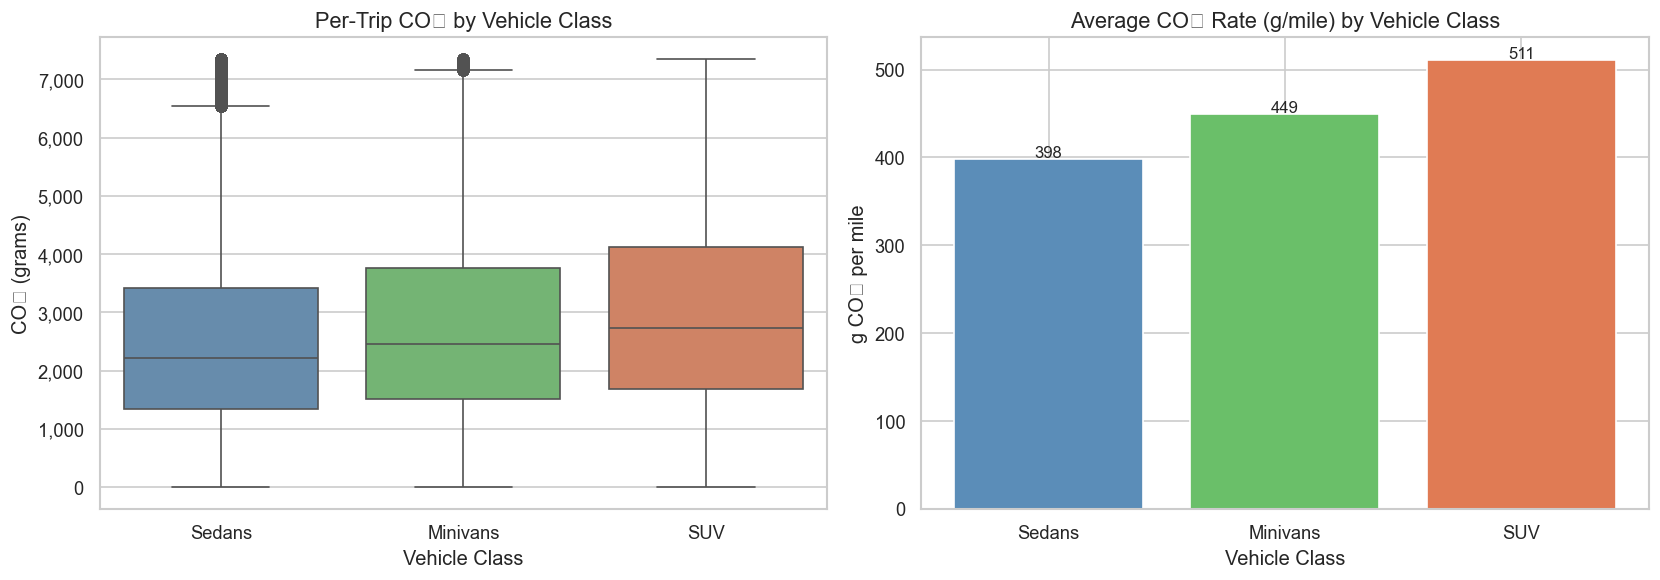

          co2TailpipeGpm  co2_total_g
VClass                               
Minivans           449.5       3029.5
SUV                511.3       3445.8
Sedans             398.4       2685.6


In [8]:
df["co2_total_g"] = df["co2TailpipeGpm"] * df["trip_miles"]

palette = {"SUV": "#e07b54", "Sedans": "#5b8db8", "Minivans": "#6abf69"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: box plot of per-trip total CO2
df_box = df[df["co2_total_g"] <= df["co2_total_g"].quantile(0.95)]
order = ["Sedans", "Minivans", "SUV"]
sns.boxplot(data=df_box, x="VClass", y="co2_total_g", order=order,
            palette=palette, ax=axes[0])
axes[0].set_title("Per-Trip CO₂ by Vehicle Class", fontsize=13)
axes[0].set_xlabel("Vehicle Class")
axes[0].set_ylabel("CO₂ (grams)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right: average emissions summary bar
avg_co2 = df.groupby("VClass")["co2TailpipeGpm"].mean().reindex(order)
axes[1].bar(avg_co2.index, avg_co2.values,
            color=[palette[v] for v in avg_co2.index], edgecolor="white")
axes[1].set_title("Average CO₂ Rate (g/mile) by Vehicle Class", fontsize=13)
axes[1].set_xlabel("Vehicle Class")
axes[1].set_ylabel("g CO₂ per mile")
for i, (v, val) in enumerate(avg_co2.items()):
    axes[1].text(i, val + 2, f"{val:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(df.groupby("VClass")[["co2TailpipeGpm", "co2_total_g"]].mean().round(1))

## 5. Shared vs. Solo Trip Analysis

`shared_match_flag = Y` means the trip was successfully pooled. Understanding what fraction of trips are already shared — and how they differ in distance — motivates the pooling optimization.

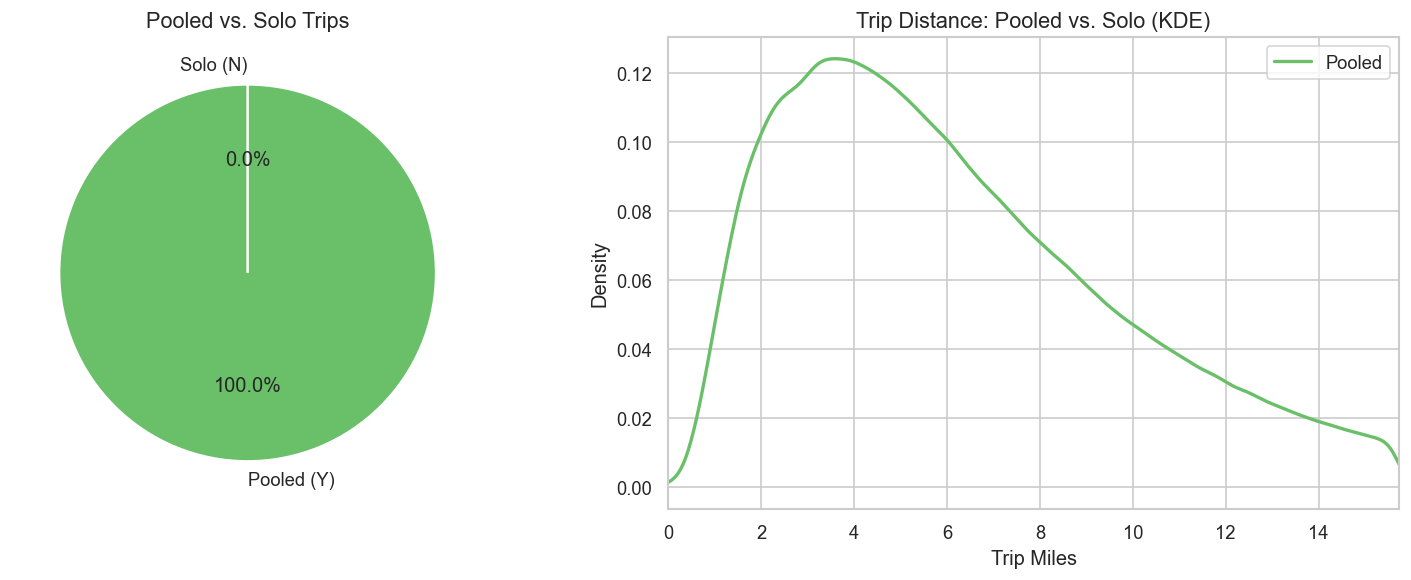

               count  mean   std  min   25%   50%   75%    max
ride_type                                                     
Pooled     1961233.0  6.08  3.48  0.0  3.33  5.43  8.29  15.73


In [10]:
share_counts = df["shared_match_flag"].fillna("N").value_counts()
labels = ["Pooled (Y)", "Solo (N)"]
values = [share_counts.get("Y", 0), share_counts.get("N", 0)]
colors = ["#6abf69", "#d9534f"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(values, labels=labels, autopct="%1.1f%%", colors=colors,
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Pooled vs. Solo Trips", fontsize=13)

# Distance distribution: pooled vs. solo
df_shared = df[(df["trip_miles"] > 0) & (df["trip_miles"] <= dist_cap)].copy()
df_shared["ride_type"] = df_shared["shared_match_flag"].map({"Y": "Pooled", "N": "Solo"}).fillna("Solo")

for rtype, color in zip(["Pooled", "Solo"], colors):
    subset = df_shared[df_shared["ride_type"] == rtype]["trip_miles"].dropna()
    if len(subset) > 1:
        subset.plot.kde(ax=axes[1], label=rtype, color=color, linewidth=2)
    else:
        print(f"Warning: not enough data to plot KDE for '{rtype}' ({len(subset)} rows)")

axes[1].set_title("Trip Distance: Pooled vs. Solo (KDE)", fontsize=13)
axes[1].set_xlabel("Trip Miles")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, dist_cap)
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_shared.groupby("ride_type")["trip_miles"].describe().round(2))

## 6. Trip Temporal Patterns (Pickup Hour)

Clustering works best when trips overlap in both space *and* time. This reveals peak demand hours where pooling opportunities are densest.

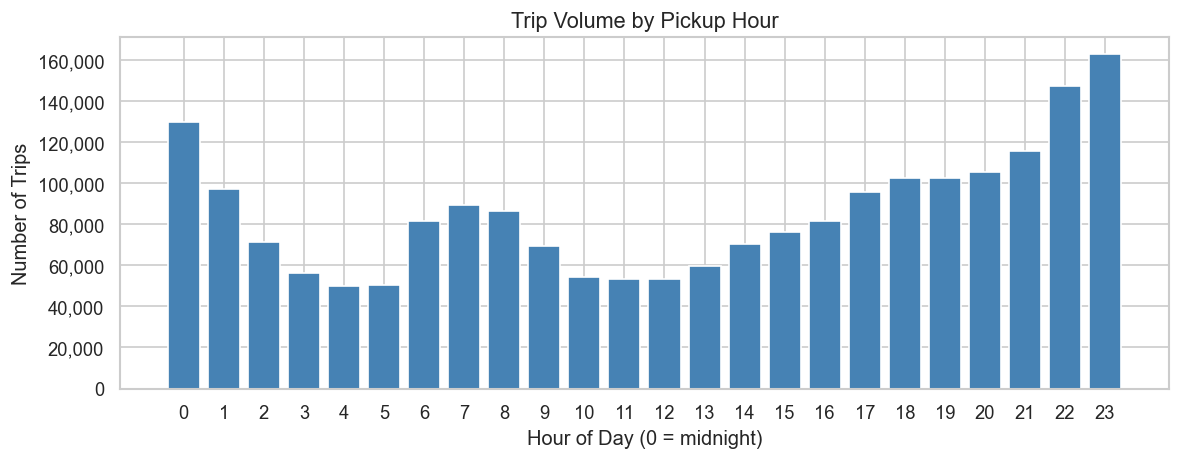

Peak hour: 23:00  (163,110 trips)


In [11]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour

hourly_counts = df.groupby("pickup_hour").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_counts.index, hourly_counts.values, color="steelblue", edgecolor="white")
ax.set_title("Trip Volume by Pickup Hour", fontsize=13)
ax.set_xlabel("Hour of Day (0 = midnight)")
ax.set_ylabel("Number of Trips")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

peak_hour = hourly_counts.idxmax()
print(f"Peak hour: {peak_hour}:00  ({hourly_counts[peak_hour]:,} trips)")